In [1]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import DeconV as dv

In [2]:
true_proportions = pd.read_csv("../../../fimm/data/xin/true.tsv", sep="\t", index_col=0)
true_proportions = true_proportions.sort_index(axis="columns").sort_index(axis="rows")
true_proportions.index.name = None
true_proportions

,alpha,beta,delta,gamma
D1,0.431818,0.136364,0.034091,0.397727
D2,0.602410,0.216867,0.060241,0.120482
D3,0.483333,0.433333,0.033333,0.050000
D4,0.492857,0.482143,0.017857,0.007143
D5,0.921212,0.066667,0.006061,0.006061
D6,0.603865,0.367150,0.024155,0.004831
H1,0.716216,0.175676,0.067568,0.040541
H10,0.418605,0.534884,0.046512,0.000000
H11,0.796610,0.169492,0.016949,0.016949
H12,0.626866,0.358209,0.014925,0.000000


In [3]:
deconv_proportions = pd.read_csv("xin/gamma/proportions_separate_bd.tsv", sep="\t", index_col=0)
deconv_proportions = deconv_proportions.sort_index(axis="columns").sort_index(axis="rows")
deconv_proportions

,alpha,beta,delta,gamma
D1,0.420414,0.167879,0.018833,0.392874
D2,0.651802,0.210447,0.037084,0.100667
D3,0.493683,0.366166,0.023568,0.116583
D4,0.573888,0.404749,0.010958,0.010406
D5,0.907878,0.085336,0.005038,0.001749
D6,0.630110,0.343028,0.007654,0.019207
H1,0.504856,0.388113,0.038827,0.068204
H10,0.552992,0.404209,0.042788,0.000011
H11,0.630142,0.286716,0.013137,0.070005
H12,0.642124,0.350263,0.007597,0.000016


In [4]:
scaden_proportions = pd.read_csv("3rd-party/scaden/xin/scaden_predictions.txt", sep="\t", index_col=0)
scaden_proportions.index = pd.read_csv("3rd-party/scaden/xin/data/xin_bulk_data.txt", sep="\t", index_col=0).columns
scaden_proportions = scaden_proportions.sort_index(axis="columns").sort_index(axis="rows")
scaden_proportions

,alpha,beta,delta,gamma
D1,0.353673,0.246749,0.076134,0.323443
D2,0.488778,0.256769,0.089132,0.165321
D3,0.359385,0.427240,0.058932,0.154442
D4,0.440841,0.426225,0.055669,0.077265
D5,0.798104,0.093063,0.028962,0.079871
D6,0.493475,0.405073,0.036325,0.065126
H1,0.626922,0.239131,0.046120,0.087826
H10,0.405432,0.434305,0.093331,0.066931
H11,0.488176,0.331384,0.060618,0.119822
H12,0.526526,0.378677,0.031744,0.063052


In [6]:
music_proportions = pd.read_csv("3rd-party/music/pbmc/music_proportions.csv", index_col=0)
music_proportions = music_proportions.sort_index(axis="columns").sort_index(axis="rows")
music_proportions.index.name = None
music_proportions

,B.cells,Monocytes,NK,T.CD4,T.CD8,UNKWN
CR3L_PBMC,0.000000,0.215874,0.449245,0.112407,0.074853,0.147620
CYFZ_PBMC,0.000000,0.178609,0.553698,0.000000,0.107171,0.160523
CZJE_PBMC,0.000000,0.172202,0.498167,0.000000,0.091301,0.238331
FLWA_PBMC,0.000202,0.221343,0.491178,0.038089,0.091391,0.157797
FY2H_PBMC,0.000000,0.294299,0.502294,0.000000,0.006486,0.196921
G4YW_PBMC,0.004814,0.188954,0.479124,0.006311,0.151029,0.169770
X36TS_PBMC,0.000358,0.267792,0.470723,0.000000,0.015175,0.245953
X453W_PBMC,0.000442,0.137611,0.605237,0.005475,0.127747,0.123488
X4DUY_PBMC,0.000347,0.100114,0.553476,0.003583,0.124845,0.217635
X684C_PBMC,0.000000,0.172961,0.525961,0.003750,0.132002,0.165326


In [8]:
melt = true_proportions.reset_index().melt(id_vars="index")
melt.rename(columns={"index": "sample", "value": "true", "variable":"cell_type"}, inplace=True)
melt["deconv"] = deconv_proportions.reset_index().melt(id_vars="index")["value"]
melt["scaden"] = scaden_proportions.reset_index().melt(id_vars="index")["value"]
melt["music"] = music_proportions.reset_index().melt(id_vars="index")["value"]
melt

,sample,cell_type,true,deconv,scaden,music
0,D1,alpha,0.431818,0.420414,0.353673,0.000000
1,D2,alpha,0.602410,0.651802,0.488778,0.000000
2,D3,alpha,0.483333,0.493683,0.359385,0.000000
3,D4,alpha,0.492857,0.573888,0.440841,0.000202
4,D5,alpha,0.921212,0.907878,0.798104,0.000000
...,...,...,...,...,...,...
67,H5,gamma,0.038462,0.046606,0.058944,0.123488
68,H6,gamma,0.020833,0.000012,0.075289,0.217635
69,H7,gamma,0.148148,0.185290,0.124015,0.165326
70,H8,gamma,0.214286,0.190957,0.197331,0.201553


In [9]:
df = true_proportions.reset_index().melt(id_vars="index")
df.rename(columns={"index": "sample", "value": "proportion", "variable":"cell_type"}, inplace=True)
df["type"] = "true"
df["error"] = None
# # df["true"] = true_proportions.reset_index().melt(id_vars="index")["value"]
# df_true = true_proportions.reset_index().melt(id_vars="index")
# df_true.rename(columns={"index": "sample", "value": "proportion", "variable":"cell_type"}, inplace=True)
# df_true["type"] = "true"
# df = pd.concat([df_est, df_true])

melt["deconv_error"] = abs(melt["deconv"] - melt["true"])
melt["scaden_error"] = abs(melt["scaden"] - melt["true"])
melt["music_error"] = abs(melt["music"] - melt["true"])

temp = melt[["sample", "cell_type", "deconv", "deconv_error"]].rename(columns={"deconv": "proportion", "deconv_error": "error"})
temp["type"] = "deconv"
df = pd.concat([df, temp])

temp = melt[["sample", "cell_type", "scaden", "scaden_error"]].rename(columns={"scaden": "proportion", "scaden_error": "error"})
temp["type"] = "scaden"
df = pd.concat([df, temp])

temp = melt[["sample", "cell_type", "music", "music_error"]].rename(columns={"music": "proportion", "music_error": "error"})
temp["type"] = "music"
df = pd.concat([df, temp])

df

,sample,cell_type,proportion,type,error
0,D1,alpha,0.431818,true,NaN
1,D2,alpha,0.602410,true,NaN
2,D3,alpha,0.483333,true,NaN
3,D4,alpha,0.492857,true,NaN
4,D5,alpha,0.921212,true,NaN
...,...,...,...,...,...
67,H5,gamma,0.123488,music,0.085027
68,H6,gamma,0.217635,music,0.196802
69,H7,gamma,0.165326,music,0.017177
70,H8,gamma,0.201553,music,0.012732


In [10]:
((melt["deconv"] - melt["true"])**2).mean()**0.5, ((melt["scaden"] - melt["true"])**2).mean()**0.5

(0.06313757486570121, 0.08124103852820205)

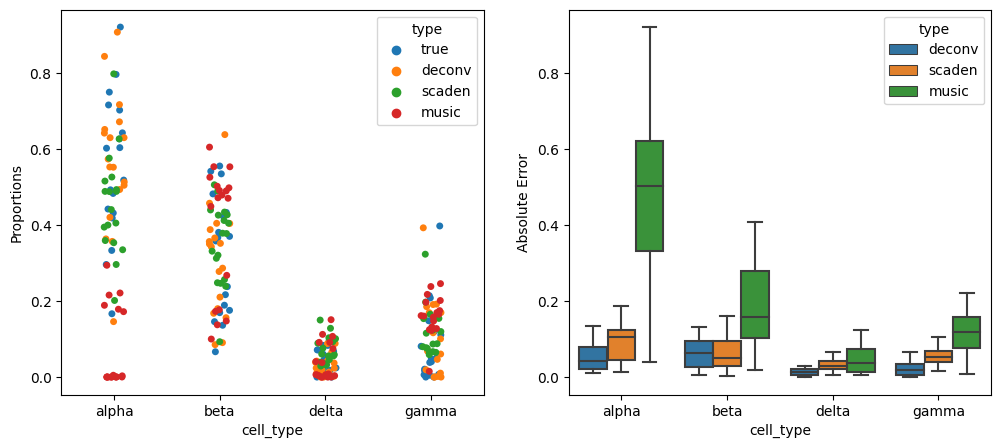

In [11]:
f, ax = plt.subplots(1,2, figsize=(12,5), dpi=100)

sns.stripplot(data=df, x="cell_type", y="proportion", hue="type", ax=ax[0])
# sns.violinplot(data=df, x="cell_type", y="proportion", hue="type", ax=ax[0], showfliers=False, split=True)
sns.boxplot(data=df[df["type"] != "true"], x="cell_type", y="error", hue="type", ax=ax[1], showfliers=False)
# sns.swarmplot(data=df[df["type"] != "true"], x="cell_type", y="error", hue="type", ax=ax[1])
# sns.violinplot(data=melt, x="cell_type", y="dist", ax=ax[1], showfliers=True)
ax[0].set_ylabel("Proportions")
ax[1].set_ylabel("Absolute Error")
# l = plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()